***image annotation*** - draw bounding boxes

*for train the model, we need know which part of the image we need to detect*

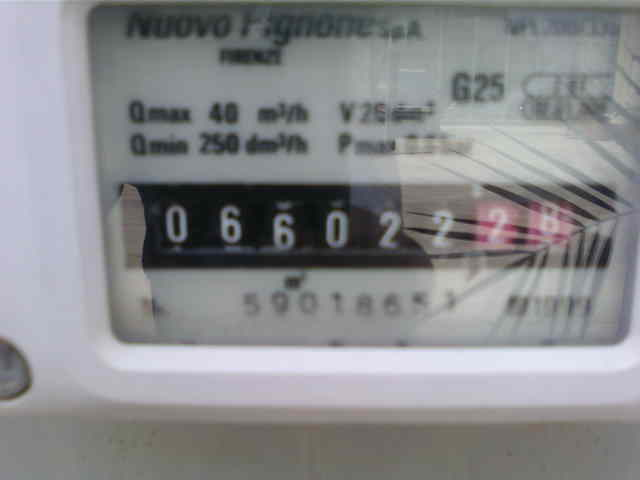

In [1]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt
img = Image.open("temp_dataset/JPEGImages/00450000102049_0.jpg")
img

*After annotation, it should be like:*

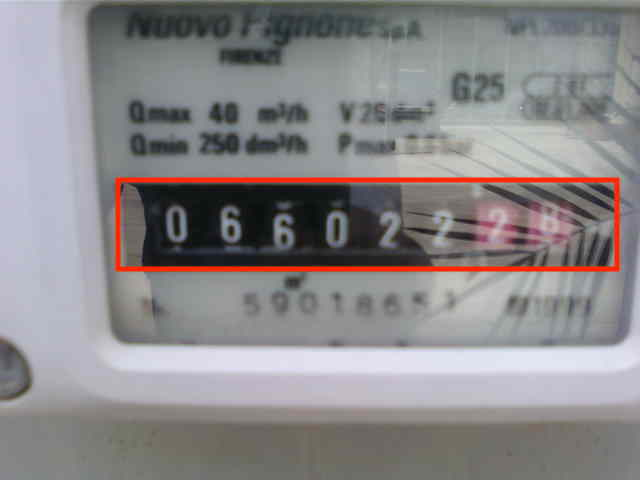

In [2]:
import matplotlib.pyplot as plt
img = Image.open("anoted_img/00450000102049_0.jpg")
img

*detect red bounding box in an image via opencv*

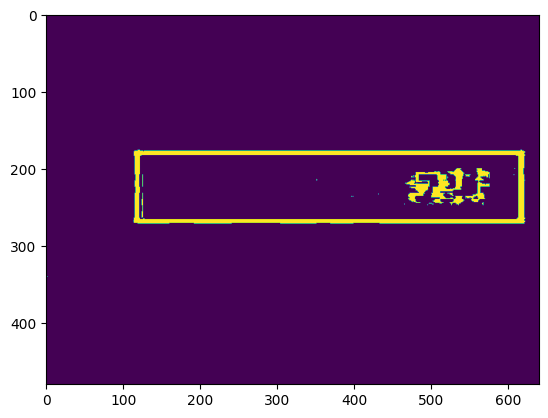

In [5]:
import numpy as np
image = cv2.imread('anoted_img/00450000102049_0.jpg')

# Convert image to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define lower and upper bounds of red color in HSV color space
lower_red = np.array([0, 50, 50])
upper_red = np.array([10, 255, 255])
mask1 = cv2.inRange(hsv, lower_red, upper_red)

lower_red = np.array([170, 50, 50])
upper_red = np.array([180, 255, 255])
mask2 = cv2.inRange(hsv, lower_red, upper_red)

# Combine masks
mask = cv2.bitwise_or(mask1, mask2)

plt.imshow(mask)
plt.show()


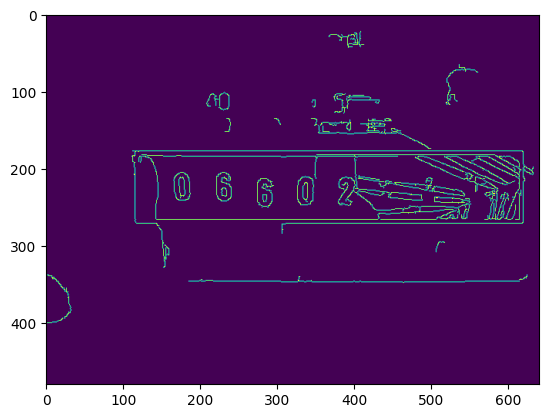

: 

In [9]:
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
contours, hierarchy = cv2.findContours(gray,cv2.RETR_LIST,cv2.CHAIN_APPROX_SIMPLE)[-2:]
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edged = cv2.Canny(gray, 30, 200)

    #cv2.rectangle(im,(x,y),(x+w,y+h),(200,0,0),2)
plt.imshow(edged)

*get the coordinates of bounding boxes*

In [4]:
# Find contours
contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Find the largest contour and draw a bounding box around it
if len(contours) > 0:
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    print("Bounding boxes: ", x,y,w,h)

Bounding boxes:  113 176 509 96


*test on the coordinates find above*

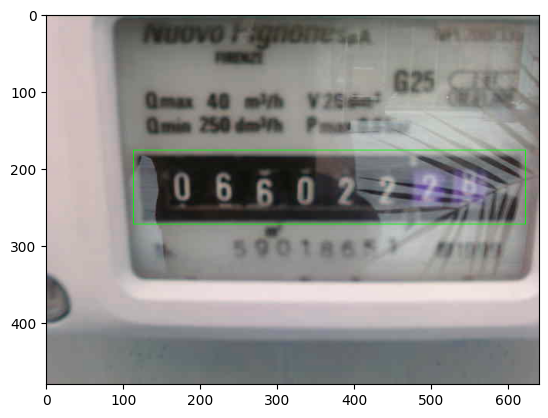

In [5]:
start_point = (113, 176)
image = cv2.imread("temp_dataset/JPEGImages/00450000102049_0.jpg")

cv2.rectangle(image, (x, y), (x+w, y+h), color = (0, 255, 0), thickness = 1)
plt.imshow(image)
plt.show()

*After we annotate all the data images, put everything together and create a dataset for our model*

In [6]:
#helper function to get the contours
def get_contour(image):
    # Convert image to HSV color space
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define lower and upper bounds of red color in HSV color space
    lower_red = np.array([0, 50, 50])
    upper_red = np.array([10, 255, 255])
    mask1 = cv2.inRange(hsv, lower_red, upper_red)

    lower_red = np.array([170, 50, 50])
    upper_red = np.array([180, 255, 255])
    mask2 = cv2.inRange(hsv, lower_red, upper_red)

    # Combine masks
    mask = cv2.bitwise_or(mask1, mask2)
    
    # Find contours
    contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Find the largest contour and draw a bounding box around it
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
    
    return x,y,w,h

#test
image = cv2.imread("anoted_img/00450000102049_0.jpg")
get_contour(image)

(113, 176, 509, 96)

In [7]:
import os
import numpy as np
import torch
from PIL import Image
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from functools import lru_cache
import nb_copy as nb
import sys
    # caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, 'detection/')

from engine import train_one_epoch, evaluate
import utils
import transforms as T

def get_transform(train):
    transforms = []
    transforms.append(T.PILToTensor())
    transforms.append(T.ConvertImageDtype(torch.float))
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    return T.Compose(transforms)

class MeterReadingDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        # load all image files, sorting them to
        # ensure that they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(root, "JPEGImages"))))  # this will be the orginal image
        self.masks = list(sorted(os.listdir(os.path.join(root, "annotation")))) # this will be the annotated image

    def __getitem__(self, idx):
        # load images and masks
        img_path = os.path.join(self.root, "JPEGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "annotation", self.masks[idx])
        img = Image.open(img_path).convert("RGB")
    
        anotate_img = cv2.imread(mask_path)
        x,y,w,h = get_contour(np.array(anotate_img))
        xmax = x + w
        ymax = y + h
        xmin = x
        ymin = y
        boxes = []
        boxes.append([xmin, ymin, xmax, ymax])
    
        # convert everything into a torch.Tensor
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        # there is only one class
        labels = torch.ones((1,), dtype=torch.int64)

        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # suppose all instances are not crowd
        iscrowd = torch.zeros((1,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

In [8]:
#test
MeterReadingDataset("temp_dataset",get_transform(train=True)).__getitem__(2)

(tensor([[[0.4000, 0.4039, 0.4118,  ..., 0.1686, 0.1725, 0.1765],
          [0.4078, 0.4078, 0.4118,  ..., 0.1647, 0.1686, 0.1725],
          [0.4118, 0.4118, 0.4118,  ..., 0.1647, 0.1686, 0.1725],
          ...,
          [0.2941, 0.2980, 0.2980,  ..., 0.6431, 0.6627, 0.6941],
          [0.2902, 0.2902, 0.2941,  ..., 0.6118, 0.6471, 0.6824],
          [0.2863, 0.2863, 0.2902,  ..., 0.5882, 0.6314, 0.6706]],
 
         [[0.4275, 0.4314, 0.4392,  ..., 0.1216, 0.1294, 0.1333],
          [0.4353, 0.4353, 0.4392,  ..., 0.1176, 0.1255, 0.1294],
          [0.4353, 0.4353, 0.4353,  ..., 0.1176, 0.1255, 0.1294],
          ...,
          [0.3608, 0.3647, 0.3647,  ..., 0.6471, 0.6667, 0.6980],
          [0.3569, 0.3569, 0.3608,  ..., 0.6157, 0.6471, 0.6824],
          [0.3529, 0.3529, 0.3569,  ..., 0.5922, 0.6314, 0.6706]],
 
         [[0.4000, 0.4039, 0.4118,  ..., 0.0588, 0.0588, 0.0627],
          [0.4078, 0.4078, 0.4118,  ..., 0.0549, 0.0549, 0.0588],
          [0.4196, 0.4196, 0.4196,  ...,

*load our faster rcnn model*

In [9]:
def load_model():
    num_classes = 2 # meter reading and background
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


*define test and train dataloader*

In [10]:
def get_dataloader():
    # use our dataset and defined transformations
    dataset = MeterReadingDataset('temp_dataset', get_transform(train=True))
    dataset_test = MeterReadingDataset('temp_dataset', get_transform(train=False))
    # split the dataset in train and test set
    # indices = torch.randperm(len(dataset)).tolist()
    # dataset = torch.utils.data.Subset(dataset, indices[-50:])
    # dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])
    
    # define training and validation data loaders
    data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=2, shuffle=True, num_workers=4,
        collate_fn=utils.collate_fn)
    
    data_loader_test = torch.utils.data.DataLoader(
        dataset_test, batch_size=1, shuffle=False, num_workers=4,
        collate_fn=utils.collate_fn)

    return data_loader, data_loader_test

*define main function for train*

In [11]:
def main():
    # train on the GPU or on the CPU, if a GPU is not available
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

    #load data
    data_loader, data_loader_test = get_dataloader()
 
    # get the model using our helper function
    model = load_model()

    # move model to the right device
    model.to(device)
    # construct an optimizer
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005,
                                momentum=0.9, weight_decay=0.0005)
    # and a learning rate scheduler
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                   step_size=3,
                                                   gamma=0.1)

    num_epochs = 1
    for epoch in range(num_epochs):
        # train for one epoch, printing every 10 iterations
        train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=20)
        # update the learning rate
        lr_scheduler.step()
        # # evaluate on the test dataset
        #evaluate(model, data_loader_test, device=device)

In [12]:
if __name__ == "__main__":
    nb.main()

Epoch: [0]  [0/2]  eta: 0:00:12  lr: 0.005000  loss: 0.8044 (0.8044)  loss_classifier: 0.6837 (0.6837)  loss_box_reg: 0.0855 (0.0855)  loss_objectness: 0.0052 (0.0052)  loss_rpn_box_reg: 0.0300 (0.0300)  time: 6.1359  data: 1.0335
Epoch: [0]  [1/2]  eta: 0:00:04  lr: 0.005000  loss: 0.7494 (0.7769)  loss_classifier: 0.6604 (0.6720)  loss_box_reg: 0.0396 (0.0626)  loss_objectness: 0.0052 (0.0199)  loss_rpn_box_reg: 0.0147 (0.0224)  time: 4.0628  data: 0.5170
Epoch: [0] Total time: 0:00:18 (9.0660 s / it)
